In [3]:
import sys
sys.path.insert(0, "..")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from neural_capm.data.loaders import load_price_series, compute_returns
from neural_capm.finance.rolling_beta import compute_rolling_beta

In [5]:
reliance_prices = load_price_series("RELIANCE.NS")
hdfc_prices = load_price_series("HDFCBANK.NS")
index_prices = load_price_series("^NSEI")

reliance_ret = compute_returns(reliance_prices)
hdfc_ret = compute_returns(hdfc_prices)
index_ret = compute_returns(index_prices)

print(reliance_ret.dtype, hdfc_ret.dtype, index_ret.dtype)

float64 float64 float64


In [6]:
reliance_beta = compute_rolling_beta(reliance_ret, index_ret, window=250)
hdfc_beta = compute_rolling_beta(hdfc_ret, index_ret, window=250)

print(reliance_beta.describe())
print(hdfc_beta.describe())

count    2208.000000
mean        1.095659
std         0.168883
min         0.654869
25%         1.001076
50%         1.108688
75%         1.193524
max         1.505779
Name: rolling_beta, dtype: float64
count    2208.000000
mean        0.959661
std         0.183884
min         0.665361
25%         0.770044
50%         1.013347
75%         1.097989
max         1.306514
Name: rolling_beta, dtype: float64


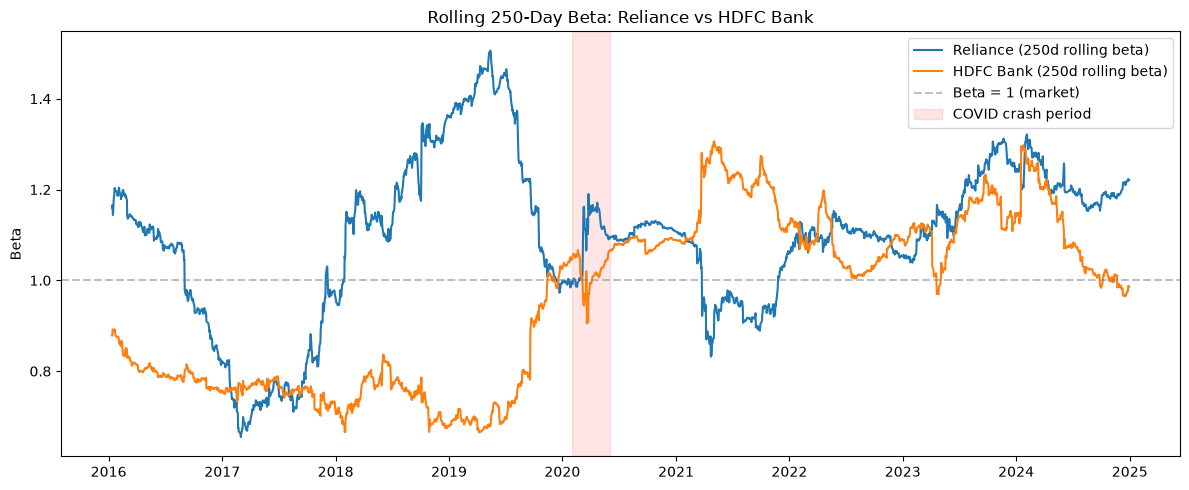

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(reliance_beta.index, reliance_beta.values, label="Reliance (250d rolling beta)")
ax.plot(hdfc_beta.index, hdfc_beta.values, label="HDFC Bank (250d rolling beta)")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Beta = 1 (market)")
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"),
           color="red", alpha=0.1, label="COVID crash period")
ax.set_title("Rolling 250-Day Beta: Reliance vs HDFC Bank")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
import os
os.makedirs("../results/figures", exist_ok=True)
fig.savefig("../results/figures/rolling_beta_reliance_hdfc.png", dpi=150)
print("saved.")

saved.
